In [15]:
import icarusplot
import uproot
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import glob
from tqdm import tqdm
from multiprocessing import Pool

In [16]:
InputDir = '/pnfs/dune/scratch/users/jskim/gundam/grid_outputs/250627_BadRegionRejection/LCurve'

In [34]:
WD = '/exp/dune/app/users/jskim/gundam_grid/GUNDAM-1.9.X/work/run_configs/260311_LogNormal/TemplateSumRegCov_LCurve'

In [35]:
PlotDir = f'{WD}/plots'
os.system(f'mkdir -p {PlotDir}')

0

In [72]:
# VariableXName = 'MuonCos'
# VariableYName = 'MuonProtonCos'

VariableXName = 'deltaPT'
VariableYName = 'deltaalphaT'

In [ ]:
def process_single_strength(Log10Strenght):

    Strenght = pow(10., Log10Strenght)

    RegStrName = f'{Log10Strenght:1.3f}'
    this_FitterOutputFilePath = f'{InputDir}/output_Fitter_{VariableXName}_and_{VariableYName}_Log10Strength{RegStrName}.root'

    try:
        with uproot.open(this_FitterOutputFilePath) as f:
            if 'FitterEngine/postFit/bestFitStats' not in f:
                return None
            
            df_bfstat = f['FitterEngine/postFit/bestFitStats'].arrays(library='pd').iloc[0]
            df_hesse = f['FitterEngine/postFit/hesseStats'].arrays(library='pd').iloc[0]
            
            if df_hesse['covStatusCode'] != 3:
                return None

            LLH_Stat = df_bfstat['statLikelihoodAtBestFit']
            LLH_Reg_VarX = df_bfstat[f'Template_Parameter_{VariableXName}']['llhPenalty']
            LLH_Reg_VarY = df_bfstat[f'Template_Parameter_{VariableYName}']['llhPenalty']
            
            LLH_Reg = LLH_Reg_VarX + LLH_Reg_VarY
            LLH_NormReg = LLH_Reg / Strenght

            return (Strenght, LLH_Stat, LLH_Reg, LLH_NormReg)
    except Exception as e:
        return None

In [73]:
UseCSV = True

In [74]:
df_path = f'{WD}/summary_{VariableXName}_{VariableYName}.csv'

if UseCSV:

    print('Using csv')
    df = pd.read_csv(df_path)

    Lambdas = df['lambda'].to_numpy()
    LLHStats = df['llhStat'].to_numpy()
    LLHRegs = df['llhReg'].to_numpy()
    LLHNormRegs = df['llhRegOverlambda'].to_numpy()
    curvature = df['curvature'].to_numpy()

    Log10Strengths = np.log10(Lambdas)

else:

    print('Creating csv')

    Log10Strengths = []
    flist = glob.glob(f'{InputDir}/output_Fitter_{VariableXName}_and_{VariableYName}_Log10Strength*.root')
    for fpath in flist:
        fname = fpath.split('/')[-1]
        this_strength = fname.replace(f'output_Fitter_{VariableXName}_and_{VariableYName}_Log10Strength','').replace('.root','')
        Log10Strengths.append( float(this_strength) )

    Log10Strengths.sort()
    Log10Strengths = np.array(Log10Strengths)

    num_cores = 8
    with Pool(processes=num_cores) as pool:
        results = list(tqdm(pool.imap(process_single_strength, Log10Strengths), total=len(Log10Strengths)))

    Lambdas, LLHStats, LLHRegs, LLHNormRegs = map(np.array, zip(*results))

    dx = np.gradient(LLHStats)
    dy = np.gradient(LLHNormRegs)

    ddx = np.gradient(dx)
    ddy = np.gradient(dy)

    # Compute curvature
    curvature = np.abs(dx * ddy - dy * ddx) / (dx**2 + dy**2)**1.5

    df = pd.DataFrame(
        {
            'lambda': Lambdas,
            'llhStat': LLHStats,
            'llhReg': LLHRegs,
            'llhRegOverlambda': LLHNormRegs,
            'curvature': curvature,
        }
    )
    df.to_csv(df_path)

Using csv


1036060939.6698276
0.0709577767963388


Text(0, 0.5, 'Curvature')

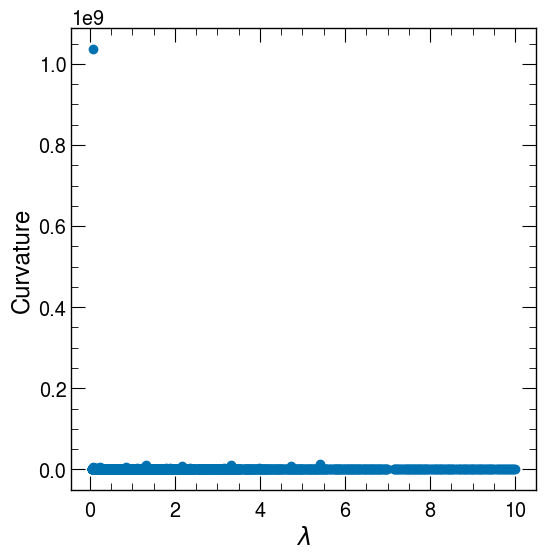

In [75]:
index_Max_Curvature = np.argmax(curvature)

print(curvature[index_Max_Curvature])
print(Lambdas[index_Max_Curvature])

fig, ax = plt.subplots(figsize=(6,6))

ax.plot(
    Lambdas,
    curvature,
    marker='o',
    linestyle='',
)

ax.set_xlabel(r'$\lambda$')
ax.set_ylabel('Curvature')

In [76]:
Mask = Lambdas<1.0

curvature_Mask = curvature[Mask]
LLHStats_Mask = LLHStats[Mask]
Lambdas_Mask = Lambdas[Mask]
LLHNormRegs_Mask = LLHNormRegs[Mask]

max_index = np.argmax(curvature_Mask)

print(Lambdas[max_index])
print(np.log10(Lambdas[max_index]))

0.0709577767963388
-1.1490000000000005


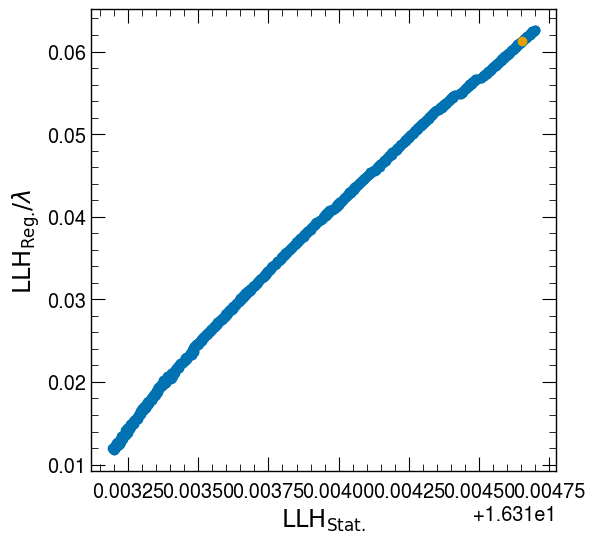

In [77]:
fig, ax = plt.subplots(figsize=(6,6))

ax.plot(
    LLHStats_Mask,
    LLHNormRegs_Mask,
    marker='o',
    linestyle='',
)

ax.plot(
    LLHStats_Mask[max_index],
    LLHNormRegs_Mask[max_index],
    marker='o',
    linestyle='',
)


# ax.set_xlim(30.0, 33.0)
# ax.set_ylim(0., 3.0)

# for i, Lambda in enumerate(Lambdas):
#     if i % 2 == 0:
#         ax.annotate(r'$\lambda$='+'%1.2f'%(Lambda), (LLHStats[i], LLHNormRegs[i]))


ax.set_xlabel(r'$\mathrm{LLH}_{\text{Stat.}}$')

ax.set_ylabel(r'$\mathrm{LLH}_{\text{Reg.}}/\lambda$')

fig.savefig(f'{PlotDir}/{VariableXName}_{VariableYName}_LCurve.pdf', bbox_inches='tight')